<a href="https://colab.research.google.com/github/Harini-7907/HariniMowgli/blob/main/Iris_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

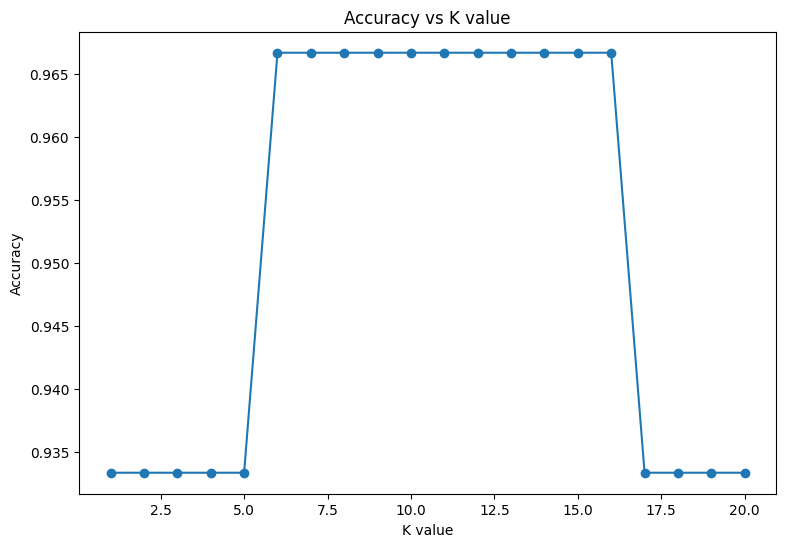

In [ ]:
accuaries = []
k_values = range(1,21)
for k_val in k_values:
  knn_temp = KNeighborsClassifier(n_neighbors=k_val)
  knn_temp.fit(X_train_scaled_optimal , y_train_optimal)
  pred_temp = knn_temp.predict(X_test_scaled_optimal)
  acc_temp = accuracy_score(y_test_optimal , pred_temp)
  accuaries.append(acc_temp)

import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
plt.plot(k_values,accuaries,marker = 'o')
plt.xlabel('K value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K value')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
iris_df = pd.read_csv('/content/Iris.csv')
print("Original DataFrame head:")
display(iris_df.head())

Original DataFrame head:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer

iris_df_with_nan = iris_df.copy()
iris_df_with_nan.loc[0, 'SepalLengthCm'] = np.nan
print("DataFrame with a missing value:")
display(iris_df_with_nan.head())

# Apply SimpleImputer with 'most_frequent' strategy
num_imputer = SimpleImputer(strategy = 'most_frequent')
iris_df_with_nan[['SepalLengthCm']] = num_imputer.fit_transform(iris_df_with_nan[['SepalLengthCm']])

print("\nDataFrame after imputing missing values:")
print(iris_df_with_nan.isnull().sum())
display(iris_df_with_nan.head())

DataFrame with a missing value:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,NaN,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



DataFrame after imputing missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.0,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
iris_df_cleaned = iris_df_with_nan.dropna()
print("DataFrame after removing missing values:")
display(iris_df_cleaned.head())

DataFrame after removing missing values:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X = iris_df_cleaned.drop(['Id', 'Species'], axis=1)
y = iris_df_cleaned['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn1 = KNeighborsClassifier(n_neighbors=3)
knn1.fit(X_train  , y_train)
pred1 = knn1.predict(X_test)
acc1 = accuracy_score(y_test , pred1)
print(acc1)

0.9333333333333333


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train_scaled  , y_train)
pred2 = knn2.predict(X_test_scaled)
acc2 = accuracy_score(y_test , pred2)
print(acc2)

0.9333333333333333


In [ ]:

from sklearn.preprocessing import LabelEncoder

X_base = iris_df_cleaned.drop(['Id', 'Species'], axis=1)
y_base_species = iris_df_cleaned['Species']

le = LabelEncoder()
y_encoded = le.fit_transform(y_base_species)

X_train_optimal, X_test_optimal, y_train_optimal, y_test_optimal = train_test_split(X_base, y_encoded, test_size=0.2, random_state=42)

scaler_optimal = StandardScaler()
X_train_scaled_optimal = scaler_optimal.fit_transform(X_train_optimal)
X_test_scaled_optimal = scaler_optimal.transform(X_test_optimal)

print("Optimal X_train_scaled_optimal (first 5 rows):\n", X_train_scaled_optimal[:5])
print("\nOptimal X_test_scaled_optimal (first 5 rows):\n", X_test_scaled_optimal[:5])
print("\nOptimal y_train_optimal (first 5 values):\n", y_train_optimal[:5])

Optimal X_train_scaled_optimal (first 5 rows):
 [[-0.86930015  0.5985787  -1.17998807 -0.93600222]
 [-0.50462312  1.96402659 -1.40980572 -1.07036201]
 [-0.2615051  -0.08414525  0.42873544  0.40759566]
 [-1.23397717 -0.08414525 -1.35235131 -1.47344137]
 [-0.99085916  1.05372799 -1.23744248 -0.80164243]]

Optimal X_test_scaled_optimal (first 5 rows):
 [[ 0.71096698 -0.3117199   0.31382661  0.13887608]
 [-0.86930015  1.73645194 -1.29489689 -1.2047218 ]
 [ 2.29123411 -0.99444384  1.8076413   1.48247397]
 [-0.13994609 -0.99444384 -0.14580867 -0.26420328]
 [ 1.07564401 -0.08414525  0.71600749  0.67631524]]

Optimal y_train_optimal (first 5 values):
 [0 0 1 0 0]


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_species = LabelEncoder()
iris_df['Species_encoded'] = le_species.fit_transform(iris_df['Species'])

print(iris_df[['Species', 'Species_encoded']])
print(iris_df.head())

            Species  Species_encoded
0       Iris-setosa                0
1       Iris-setosa                0
2       Iris-setosa                0
3       Iris-setosa                0
4       Iris-setosa                0
..              ...              ...
145  Iris-virginica                2
146  Iris-virginica                2
147  Iris-virginica                2
148  Iris-virginica                2
149  Iris-virginica                2

[150 rows x 2 columns]
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   Species_encoded  
0                0  
1        

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_to_scale = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']

iris_df_scaled = iris_df.copy()
iris_df_scaled[cols_to_scale] = scaler.fit_transform(iris_df[cols_to_scale])

print(iris_df_scaled[cols_to_scale])
print(iris_df_scaled.head())

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0        -0.900681      1.032057      -1.341272     -1.312977
1        -1.143017     -0.124958      -1.341272     -1.312977
2        -1.385353      0.337848      -1.398138     -1.312977
3        -1.506521      0.106445      -1.284407     -1.312977
4        -1.021849      1.263460      -1.341272     -1.312977
..             ...           ...            ...           ...
145       1.038005     -0.124958       0.819624      1.447956
146       0.553333     -1.281972       0.705893      0.922064
147       0.795669     -0.124958       0.819624      1.053537
148       0.432165      0.800654       0.933356      1.447956
149       0.068662     -0.124958       0.762759      0.790591

[150 rows x 4 columns]
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1      -0.900681      1.032057      -1.341272     -1.312977  Iris-setosa   
1   2      -1.143017     -0.124958      -1.341272     -1.312977  Iris-se

In [ ]:
from sklearn.model_selection import train_test_split

X_scaled = iris_df_scaled.drop(['Id', 'Species', 'Species_encoded'], axis=1)
y_scaled = iris_df_scaled['Species_encoded']

X_train_scaled_new, X_test_scaled_new, y_train_new, y_test_new = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

print("Head of X_train_scaled_new:")
display(X_train_scaled_new.head())

print("\nHead of X_test_scaled_new:")
display(X_test_scaled_new.head())

Head of X_train_scaled_new:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
22,-1.506521,1.263460,-1.568735,-1.312977
15,-0.173674,3.114684,-1.284407,-1.050031
65,1.038005,0.106445,0.364699,0.264699
11,-1.264185,0.800654,-1.227541,-1.312977
42,-1.748856,0.337848,-1.398138,-1.312977



Head of X_test_scaled_new:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
73,0.310998,-0.587764,0.535296,0.001753
18,-0.173674,1.726266,-1.170675,-1.181504
118,2.249683,-1.050569,1.786341,1.447956
78,0.189830,-0.356361,0.421564,0.396172
76,1.159173,-0.587764,0.592162,0.264699


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris_df = pd.read_csv('/content/Iris.csv')

X = iris_df.drop('Species', axis=1)
y = iris_df['Species']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 5)
Testing data shape: (30, 5)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
iris_df = pd.read_csv('/content/Iris.csv')

X = iris_df.drop('Species', axis=1)
y = iris_df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (120, 5)
Testing data shape: (30, 5)
